In [98]:
# (a)

I downloaded the XLSX file, opened it in Excel, and saved it as a CSV file using “Save As.”

In [99]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [100]:
# Print the first few rows and the number of rows.
df = pd.read_csv("hw1_real estate.csv")

print(df.head())
print("Number of rows:", len(df))

   No  X1 transaction date  X2 house age  \
0   1             2012.917          32.0   
1   2             2012.917          19.5   
2   3             2013.583          13.3   
3   4             2013.500          13.3   
4   5             2012.833           5.0   

   X3 distance to the nearest MRT station  X4 number of convenience stores  \
0                                84.87882                               10   
1                               306.59470                                9   
2                               561.98450                                5   
3                               561.98450                                5   
4                               390.56840                                5   

   X5 latitude  X6 longitude  Y house price of unit area  
0     24.98298     121.54024                        37.9  
1     24.98034     121.53951                        42.2  
2     24.98746     121.54391                        47.3  
3     24.98746     121.54391  

In [101]:
# For each column write one line: what it is, its units, its range.
for col in df.columns:
    print(col)
    print("  min =", df[col].min())
    print("  max =", df[col].max())

No
  min = 1
  max = 414
X1 transaction date
  min = 2012.667
  max = 2013.583
X2 house age
  min = 0.0
  max = 43.8
X3 distance to the nearest MRT station
  min = 23.38284
  max = 6488.021
X4 number of convenience stores
  min = 0
  max = 10
X5 latitude
  min = 24.93207
  max = 25.01459
X6 longitude
  min = 121.47353
  max = 121.56627
Y house price of unit area
  min = 7.6
  max = 117.5


No: Record index; no; range: 1–414.
X1 Transaction date: Date of the house transaction; year; range: 2012.667–2013.583.
X2 House age: Age of the house; years; range: 0–43.8 years.
X3 Distance to MRT: Distance to the nearest MRT station; meters; range: 23.38–6488.02 m.
X4 Convenience stores: Number of convenience stores nearby; count; range: 0–10.
X5 Latitude: Geographic latitude; degrees; range: 24.93207–25.01459°.
X6 Longitude: Geographic longitude; degrees; range: 121.47353–121.56627°.
Y House price: House price per unit area; not mentioned; range: 7.6–117.5.

In [102]:
# Look at the target (price per unit area) and at least two features with
# histograms. Anything odd? Missing values, a few houses far from everything else,
# a feature with a strange scale – write down what you see.

Target: Y house price of unit area
Feature 1: X2 house age
Feature 2: X3 distance to the nearest MRT station

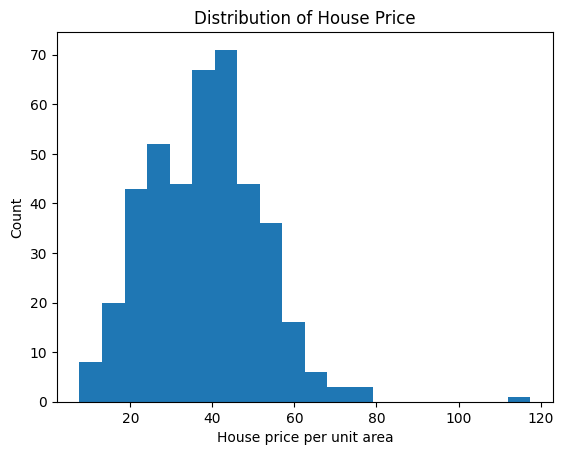

In [103]:
# Target: house price per unit area
plt.hist(df["Y house price of unit area"], bins=20)

plt.xlabel("House price per unit area")
plt.ylabel("Count")
plt.title("Distribution of House Price")

plt.show()


Most house prices are between about 20 and 60, but there is a high-price outlier near 117.5

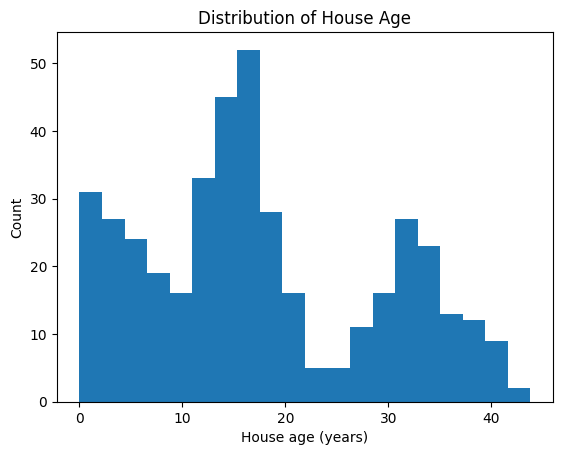

In [104]:
# Feature 1: house age
plt.hist(df["X2 house age"], bins=20)

plt.xlabel("House age (years)")
plt.ylabel("Count")
plt.title("Distribution of House Age")

plt.show()

House age ranges from 0 to 43.8 years and no obvious outlier.

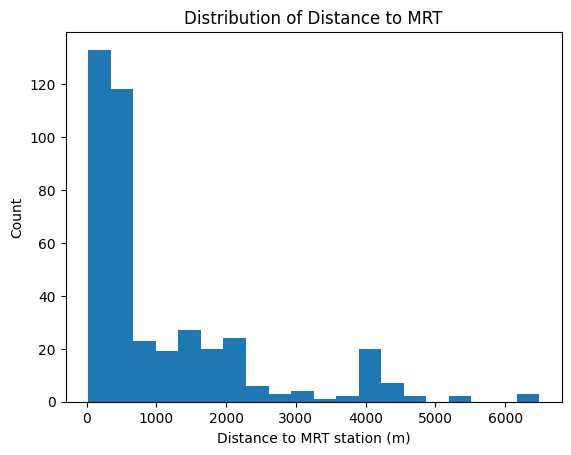

In [105]:
# Feature 2: distance to nearest MRT station
plt.hist(df["X3 distance to the nearest MRT station"], bins=20)

plt.xlabel("Distance to MRT station (m)")
plt.ylabel("Count")
plt.title("Distribution of Distance to MRT")

plt.show()

Most houses are relatively close to an MRT station, while a few are more than 5000–6000 m away. Its numerical scale is also much larger than that of house age.

In [106]:
# missing values
print(df.isnull().sum())

No                                        0
X1 transaction date                       0
X2 house age                              0
X3 distance to the nearest MRT station    0
X4 number of convenience stores           0
X5 latitude                               0
X6 longitude                              0
Y house price of unit area                0
dtype: int64


no missing values

In [107]:
# (b)
 # Write the mean squared error loss, derive ωL/ωw0 and ωL/ωw1 by hand (show the two lines of algebra)

$$
\hat{y}_i = w_0 + w_1 x_i
$$

The mean squared error loss is

$$
L = \frac{1}{N}\sum_{i=1}^{N}(\hat{y}_i-y_i)^2
= \frac{1}{N}\sum_{i=1}^{N}(w_0+w_1x_i-y_i)^2
$$

For $w_0$,

$$
\frac{\partial L}{\partial w_0}
=
\frac{1}{N}\sum_{i=1}^{N}
2(w_0+w_1x_i-y_i)
\frac{\partial(w_0+w_1x_i-y_i)}{\partial w_0}
$$

$$
\frac{\partial L}{\partial w_0}
=
\frac{2}{N}\sum_{i=1}^{N}(w_0+w_1x_i-y_i)
$$

For $w_1$,

$$
\frac{\partial L}{\partial w_1}
=
\frac{1}{N}\sum_{i=1}^{N}
2(w_0+w_1x_i-y_i)
\frac{\partial(w_0+w_1x_i-y_i)}{\partial w_1}
$$

$$
\frac{\partial L}{\partial w_1}
=
\frac{2}{N}\sum_{i=1}^{N}(w_0+w_1x_i-y_i)x_i
$$

In [108]:
# and code gradient descent with those two expressions
 # a loop, two updates per iteration.
 # the final w0, w1 and loss

x = df["X2 house age"].to_numpy()
y = df["Y house price of unit area"].to_numpy()
w0 = 0.0
w1 = 0.0
learning_rate = 0.001
epochs = 10000

loss_history = []

for epoch in range(epochs): # a loop
    # prediction
    y_pred = w0 + w1 * x
    # mean squared error
    loss = np.mean((y_pred - y)**2)
    loss_history.append(loss)
    # gradients derived above
    dw0 = 2 * np.mean(y_pred - y)
    dw1 = 2 * np.mean((y_pred - y) * x)
    # two updates per iteration
    w0 = w0 - learning_rate * dw0
    w1 = w1 - learning_rate * dw1

print("w0 =", w0)
print("w1 =", w1)
print("Final loss =", loss_history[-1])

w0 = 42.310810117843985
w1 = -0.24653410917159566
Final loss = 176.50496288348504


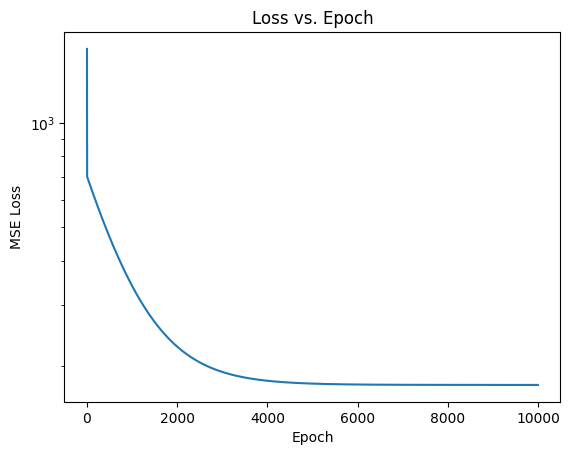

In [109]:
# the learning rate and number of epochs you used, and how you chose them
# loss against epoch (log scale on y helps), showing that it converges;

loss_history.append(loss)

plt.plot(loss_history)

plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.title("Loss vs. Epoch")
plt.yscale("log")

plt.show()

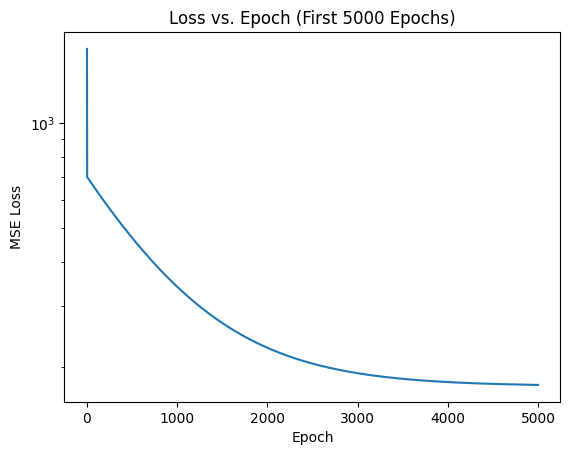

In [110]:
plt.plot(loss_history[:5000])

plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.title("Loss vs. Epoch (First 5000 Epochs)")
plt.yscale("log")

plt.show()

I choose learning rate of 0.001 and 10000 epochs. I chose this learning rate because it produced stable decrease in loss without oscillation and divergence. I compared 10000 epochs with 5000 epochs, the loss was still decreasing during 5000 epochs, while 10000 epochs curve became nearly flat about 6000 epochs

The MSE loss decreases rapidly during early epochs and then decreases slowly. After about 5000 epochs, the curve becomes nearly flat, showing the gradient descent has converged.

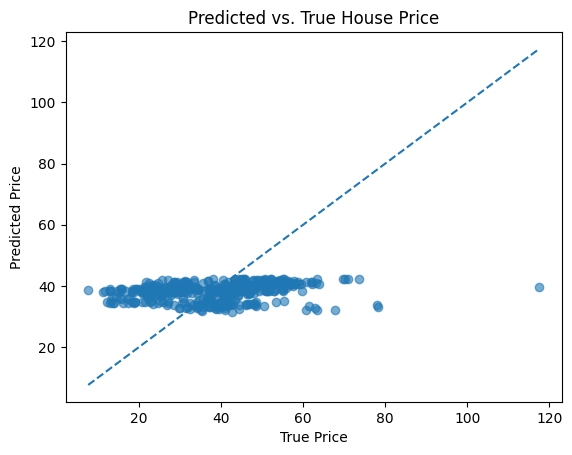

In [111]:
# a scatter plot of predicted against true price.

# Final predictions
y_pred = w0 + w1 * x

# Scatter plot: predicted vs. true price
plt.scatter(y, y_pred, alpha=0.6)

# Ideal prediction line: y_pred = y
min_val = min(y.min(), y_pred.min())
max_val = max(y.max(), y_pred.max())
plt.plot([min_val, max_val], [min_val, max_val], '--')

plt.xlabel("True Price")
plt.ylabel("Predicted Price")
plt.title("Predicted vs. True House Price")
plt.show()

The predicted prices are concentrated in a narrow range of approximately 32-43, while the true prices vary much more widely. Therefore, house age is not a good predictor of house price.

In [112]:
# (c)
 # Add the distance to the nearest MRT station, and if you like one more feature
 # y = w0 + w1x1 + w2x2(+...)
 # Write the model and the gradient in vector form, ˆy = w→x with a constant 1 appended to x

house age = $x_1$， distance to the nearest MRT station = $x_2$.

The model is

$$
\hat{y}_i = w_0 + w_1x_{i1} + w_2x_{i2}.
$$

Appending a constant 1 to each feature vector

$$
\vec{x}_i =
\begin{bmatrix}
1\\
x_{i1}\\
x_{i2}
\end{bmatrix},
\qquad
\vec{w} =
\begin{bmatrix}
w_0\\
w_1\\
w_2
\end{bmatrix}.
$$

model written in vector form

$$
\hat{y}_i = \vec{w}\cdot\vec{x}_i.
$$

mean squared error

$$
L =
\frac{1}{N}\sum_{i=1}^{N}
(\hat{y}_i-y_i)^2.
$$

gradient in vector form

$$
\nabla_{\vec{w}}L
=
\frac{2}{N}
\sum_{i=1}^{N}
(\hat{y}_i-y_i)\vec{x}_i.
$$

gradient descent update

$$
\vec{w}
\leftarrow
\vec{w}
-
\eta\nabla_{\vec{w}}L.
$$

In [113]:
# rewrite your code so that it works for any number of features.

# Raw features
x1 = df["X2 house age"].to_numpy()
x2 = df["X3 distance to the nearest MRT station"].to_numpy()
y = df["Y house price of unit area"].to_numpy()

# Feature matrix with a constant 1 for the intercept
X_raw = np.column_stack((np.ones(len(y)), x1, x2))

print(X_raw.shape)
print(X_raw[:5])

(414, 3)
[[  1.       32.       84.87882]
 [  1.       19.5     306.5947 ]
 [  1.       13.3     561.9845 ]
 [  1.       13.3     561.9845 ]
 [  1.        5.      390.5684 ]]


In [114]:
# Distance to MRT is in meters and runs to several thousand; house age runs to about 40.
# Try gradient descent on the raw features first and see what happens.

# Gradient descent for any number of features
w = np.zeros(X_raw.shape[1])
learning_rate = 0.001
epochs = 10000
loss_raw = []

for epoch in range(epochs):
    # Prediction
    y_pred = X_raw @ w
    # MSE loss
    loss = np.mean((y_pred - y)**2)
    loss_raw.append(loss)
    # Gradient
    gradient = (2 / len(y)) * X_raw.T @ (y_pred - y)
    # Update all weights
    w = w - learning_rate * gradient

print("Final weights:", w)
print("Final loss:", loss_raw[-1])

/tmp/ipykernel_5390/1537648871.py:14: RuntimeWarning: overflow encountered in square
  loss = np.mean((y_pred - y)**2)
/usr/local/lib/python3.13/dist-packages/numpy/_core/_methods.py:136: RuntimeWarning: overflow encountered in reduce
  ret = umr_sum(arr, axis, dtype, out, keepdims, where=where)
/tmp/ipykernel_5390/1537648871.py:12: RuntimeWarning: overflow encountered in matmul
  y_pred = X_raw @ w
/tmp/ipykernel_5390/1537648871.py:17: RuntimeWarning: overflow encountered in matmul
  gradient = (2 / len(y)) * X_raw.T @ (y_pred - y)
/tmp/ipykernel_5390/1537648871.py:12: RuntimeWarning: invalid value encountered in matmul
  y_pred = X_raw @ w


Final weights: [nan nan nan]
Final loss: nan


Using the raw features with a learning rate of 0.001 caused gradient descent to diverge. The weights and loss became nan. This is because large difference between feature scales produces large gradients.

In [115]:
# Then normalize the features (subtract the mean, divide by the standard deviation) and try again.

# normalize
x1_norm = (x1 - np.mean(x1)) / np.std(x1)
x2_norm = (x2 - np.mean(x2)) / np.std(x2)

# add the constant 1 for the intercept
X_norm = np.column_stack((np.ones(len(y)), x1_norm, x2_norm))

print(X_norm[:5])
print("House age mean:", np.mean(x1_norm))
print("House age std:", np.std(x1_norm))
print("MRT distance mean:", np.mean(x2_norm))
print("MRT distance std:", np.std(x2_norm))

[[ 1.          1.25562833 -0.79249504]
 [ 1.          0.15708622 -0.61661163]
 [ 1.         -0.38779067 -0.41401527]
 [ 1.         -0.38779067 -0.41401527]
 [ 1.         -1.11722264 -0.54999673]]
House age mean: -9.225041557271832e-17
House age std: 1.0
MRT distance mean: -1.265761515997763e-16
MRT distance std: 1.0


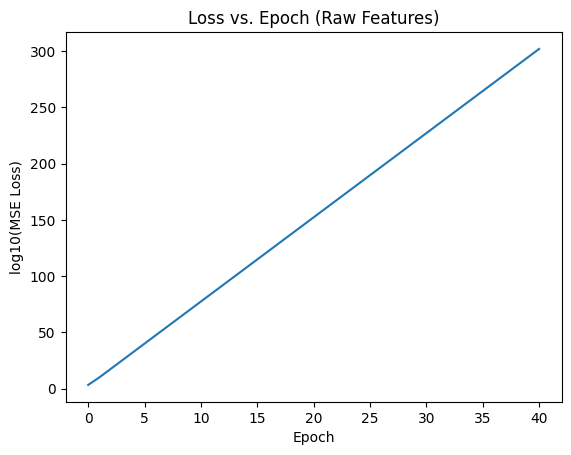

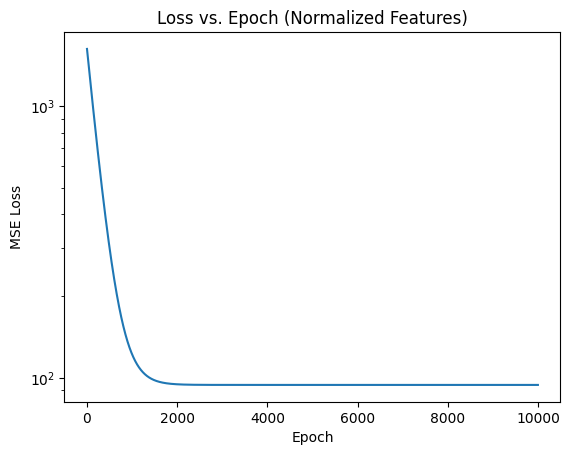

In [116]:
# show both loss curves, and explain what went wrong the first time and why normalizing fixes it.

# raw
finite_raw = np.array(loss_raw)
finite_raw = finite_raw[np.isfinite(finite_raw)]

log_raw = np.log10(finite_raw)

plt.plot(log_raw)
plt.xlabel("Epoch")
plt.ylabel("log10(MSE Loss)")
plt.title("Loss vs. Epoch (Raw Features)")
plt.show()

# Normalized features
w_norm = np.zeros(X_norm.shape[1])
learning_rate = 0.001
epochs = 10000
loss_norm = []

for epoch in range(epochs):
    y_pred_norm = X_norm @ w_norm
    loss = np.mean((y_pred_norm - y)**2)
    loss_norm.append(loss)
    gradient = (2 / len(y)) * X_norm.T @ (y_pred_norm - y)
    w_norm = w_norm - learning_rate * gradient
plt.plot(loss_norm)
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.title("Loss vs. Epoch (Normalized Features)")
plt.yscale("log")
plt.show()

With the raw features, the loss increases extremely rapidly and gradient descent diverges. The log10(MSE) reaches about 300 after only 40 epochs, after which numerical overflow produces NaN values.
After normalization, both features have approximately zero mean and unit standard deviation. Their scales therefore become comparable, the gradient updates become stable, and the loss decreases smoothly and converges.

In [117]:
# report the final weights and loss, and compare the loss to (b)

# Gradient descent with normalized features
w_norm = np.zeros(X_norm.shape[1])
learning_rate = 0.001
epochs = 10000
loss_norm = []

for epoch in range(epochs):
    # Prediction
    y_pred_norm = X_norm @ w_norm
    # MSE loss
    loss = np.mean((y_pred_norm - y)**2)
    loss_norm.append(loss)
    # Gradient
    gradient = (2 / len(y)) * X_norm.T @ (y_pred_norm - y)
    # Update all weights
    w_norm = w_norm - learning_rate * gradient

print("Final weights:", w_norm)
print("Final loss:", loss_norm[-1])

Final weights: [37.98019316 -2.62878616 -9.08707399]
Final loss: 93.97976963938088


After normalization, the final weights are approximately [37.98,-2.63,-9.09], and the final MSE loss is approximately 93.98. In part (b), using house age alone gave a final loss of approximately 176.50.
Adding distance to the nearest MRT station therefore reduces the MSE by about 46.8%, indicating that MRT distance provides useful additional information for predicting house price.

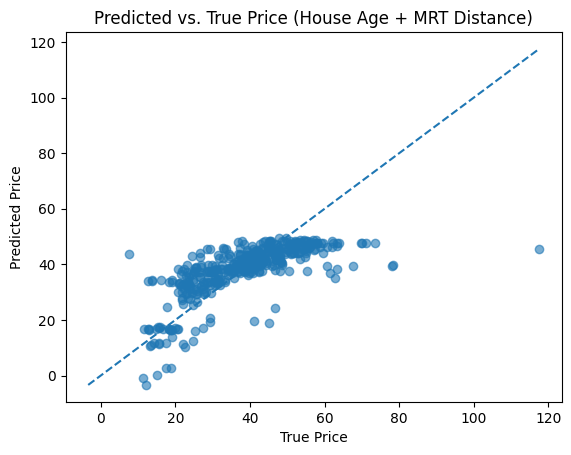

In [118]:
# (d)
 # Predicted vs. true price for the multi-feature model

y_pred_multi = X_norm @ w_norm

plt.scatter(y, y_pred_multi, alpha=0.6)

min_val = min(y.min(), y_pred_multi.min())
max_val = max(y.max(), y_pred_multi.max())

plt.plot([min_val, max_val],
         [min_val, max_val], '--')
plt.xlabel("True Price")
plt.ylabel("Predicted Price")
plt.title("Predicted vs. True Price (House Age + MRT Distance)")
plt.show()

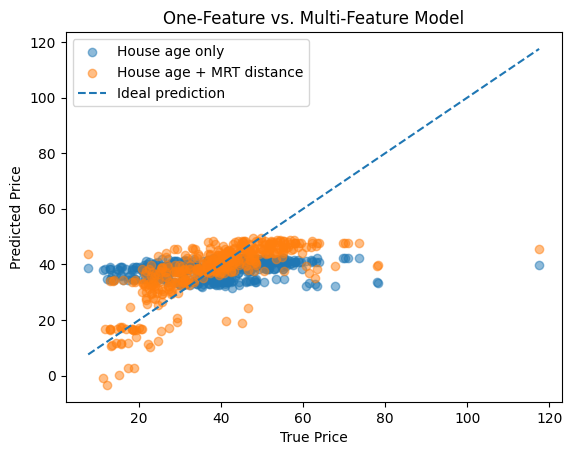

In [119]:
y_pred_one = w0 + w1 * x
y_pred_multi = X_norm @ w_norm

plt.scatter(y, y_pred_one, alpha=0.5, label="House age only")
plt.scatter(y, y_pred_multi, alpha=0.5, label="House age + MRT distance")

min_val = min(y)
max_val = max(y)

plt.plot([min_val, max_val],
         [min_val, max_val],
         '--', label="Ideal prediction")
plt.xlabel("True Price")
plt.ylabel("Predicted Price")
plt.title("One-Feature vs. Multi-Feature Model")
plt.legend()
plt.show()

The one-feature model using house age alone had a final MSE of 176.50, while the two-feature model using house age and MRT distance had a final MSE of 93.98, a reduction of about 46.8%. The predicted-vs.-true plots also show that the multi-feature model gives predictions closer to the ideal line. House age therefore carries some information about price but is a weak predictor by itself, while MRT distance provides substantial additional information.

The main limitation was feature scale. MRT distance is measured in thousands of meters, while house age is only on the scale of tens. Gradient descent on the raw features therefore diverged, whereas normalization produced stable convergence. A high-price outlier also contributes strongly to MSE because errors are squared. The learning rate of 0.001 worked well after normalization, and 10,000 epochs were sufficient but more than necessary.

In a more careful version, I would normalize the features from the start, test additional features individually, examine the outliers more carefully, compare several learning rates, and use a convergence criterion to stop training automatically.

In [120]:
# Bonus: closed-form solution using the normal equation

w_closed = np.linalg.inv(X_norm.T @ X_norm) @ X_norm.T @ y

print("Closed-form weights:", w_closed)
print("Gradient descent weights:", w_norm)

Closed-form weights: [37.98019324 -2.62878615 -9.087074  ]
Gradient descent weights: [37.98019316 -2.62878616 -9.08707399]


In [121]:
difference = np.abs(w_norm - w_closed)

print("Absolute difference:", difference)
print("Maximum difference:", np.max(difference))

Absolute difference: [7.67308919e-08 3.81962373e-09 1.79836075e-08]
Maximum difference: 7.673089186255311e-08


In [122]:
y_pred_closed = X_norm @ w_closed
loss_closed = np.mean((y_pred_closed - y)**2)

print("Closed-form loss:", loss_closed)
print("Gradient descent loss:", loss_norm[-1])

Closed-form loss: 93.97976963938086
Gradient descent loss: 93.97976963938088


In [123]:
# Find how many epochs are needed to reach the closed-form solution

w_test = np.zeros(X_norm.shape[1])

learning_rate = 0.001
tolerance = 1e-4
max_epochs = 10000

for epoch in range(max_epochs):

    y_pred = X_norm @ w_test

    gradient = (2 / len(y)) * X_norm.T @ (y_pred - y)

    w_test = w_test - learning_rate * gradient

    if np.max(np.abs(w_test - w_closed)) < tolerance:
        break

print("Epochs needed:", epoch + 1)
print("Weights at that point:", w_test)
print("Closed-form weights:", w_closed)
print("Maximum difference:", np.max(np.abs(w_test - w_closed)))

Epochs needed: 6418
Weights at that point: [37.98009338 -2.62878688 -9.08705112]
Closed-form weights: [37.98019324 -2.62878615 -9.087074  ]
Maximum difference: 9.985530725487024e-05


I defined “close enough” as a maximum absolute difference between the gradient-descent and closed-form weights of less than \(10^{-4}\). With a learning rate of \(0.001\), gradient descent first reached this tolerance after 6418 epochs. Therefore, gradient descent successfully converged to the closed-form solution.